In [4]:
# ============================================================
# W6 CELL 1 — LOAD FEATURE-ENGINEERED DATA
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load W4/W5 feature-engineered datasets
train_fe = pd.read_csv("../data/train_fe_w6.csv")
test_fe = pd.read_csv("../data/test_fe_w6.csv")

# Restore Date datatype
train_fe["Date"] = pd.to_datetime(train_fe["Date"])
test_fe["Date"] = pd.to_datetime(test_fe["Date"])

print("W6 data loaded successfully.")
print("Training shape:", train_fe.shape)
print("Test shape:", test_fe.shape)

print("\nTraining date range:")
print(train_fe["Date"].min(), "to", train_fe["Date"].max())

print("\nTest date range:")
print(test_fe["Date"].min(), "to", test_fe["Date"].max())

W6 data loaded successfully.
Training shape: (15636, 22)
Test shape: (8681, 22)

Training date range:
2015-01-02 00:00:00 to 2019-05-25 00:00:00

Test date range:
2019-05-26 00:00:00 to 2020-06-30 00:00:00


In [5]:
# ============================================================
# W6 CELL 2 — HAZARDOUS-AIR-DAY TARGET
# ============================================================

HAZARDOUS_THRESHOLD = 301

train_fe["Hazardous_Tomorrow"] = (
    train_fe["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

test_fe["Hazardous_Tomorrow"] = (
    test_fe["Tomorrow_AQI"] >= HAZARDOUS_THRESHOLD
).astype(int)

print("Hazardous threshold:", HAZARDOUS_THRESHOLD)

print("\nTraining target distribution:")
print(train_fe["Hazardous_Tomorrow"].value_counts().sort_index())

print("\nTest target distribution:")
print(test_fe["Hazardous_Tomorrow"].value_counts().sort_index())

print("\nTarget meaning:")
print("0 = Non-hazardous tomorrow")
print("1 = Hazardous tomorrow")

Hazardous threshold: 301

Training target distribution:
Hazardous_Tomorrow
0    12642
1     2994
Name: count, dtype: int64

Test target distribution:
Hazardous_Tomorrow
0    8082
1     599
Name: count, dtype: int64

Target meaning:
0 = Non-hazardous tomorrow
1 = Hazardous tomorrow


In [6]:
# ============================================================
# W6 CELL 3 — PREPARE FEATURES
# ============================================================

TARGET = "Hazardous_Tomorrow"

# Columns that must not be used as predictors
EXCLUDE_COLUMNS = [
    "City",
    "Date",
    "Tomorrow_AQI",
    "Hazardous_Tomorrow"
]

FEATURES = [
    col for col in train_fe.columns
    if col not in EXCLUDE_COLUMNS
]

X_train_tree = train_fe[FEATURES].copy()
X_test_tree = test_fe[FEATURES].copy()

y_train_tree = train_fe[TARGET].copy()
y_test_tree = test_fe[TARGET].copy()

print("Number of features:", len(FEATURES))

print("\nFeatures used by Decision Tree:")
print(FEATURES)

print("\nTraining shape:", X_train_tree.shape)
print("Test shape:", X_test_tree.shape)

print("\nMissing values:")
print("Training:", X_train_tree.isna().sum().sum())
print("Test:", X_test_tree.isna().sum().sum())

Number of features: 19

Features used by Decision Tree:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month']

Training shape: (15636, 19)
Test shape: (8681, 19)

Missing values:
Training: 30909
Test: 12262


In [8]:
# ============================================================
# W6 CELL 4 — PREPARE DATA FOR DECISION TREE
# ============================================================

from sklearn.impute import SimpleImputer

# AQI_Bucket is derived from AQI, so exclude it to avoid
# redundant information in the decision tree.
TREE_FEATURES = [
    col for col in FEATURES
    if col != "AQI_Bucket"
]

X_train_tree = train_fe[TREE_FEATURES].copy()
X_test_tree = test_fe[TREE_FEATURES].copy()

# Fit imputer ONLY on training data
imputer_tree = SimpleImputer(strategy="median")

X_train_tree_imputed = imputer_tree.fit_transform(X_train_tree)
X_test_tree_imputed = imputer_tree.transform(X_test_tree)

print("Decision Tree preprocessing completed.")

print("\nFeatures used:", len(TREE_FEATURES))
print(TREE_FEATURES)

print("\nTraining shape:", X_train_tree_imputed.shape)
print("Test shape:", X_test_tree_imputed.shape)

print("\nMissing values after imputation:")
print("Training:", np.isnan(X_train_tree_imputed).sum())
print("Test:", np.isnan(X_test_tree_imputed).sum())

Decision Tree preprocessing completed.

Features used: 18
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month']

Training shape: (15636, 18)
Test shape: (8681, 18)

Missing values after imputation:
Training: 0
Test: 0


In [9]:
# ============================================================
# W6 CELL 4 — CHECK FEATURE TYPES
# ============================================================

print("Feature data types:")
print(X_train_tree.dtypes)

print("\nCategorical features:")
print(
    X_train_tree.select_dtypes(include=["object", "category"]).columns.tolist()
)

print("\nNumeric features:")
print(
    X_train_tree.select_dtypes(include=["number"]).columns.tolist()
)

Feature data types:
PM2.5            float64
PM10             float64
NO               float64
NO2              float64
NOx              float64
NH3              float64
CO               float64
SO2              float64
O3               float64
Benzene          float64
Toluene          float64
Xylene           float64
AQI              float64
AQI_Current      float64
AQI_Lag1         float64
AQI_3Day_Mean    float64
DayOfWeek          int64
Month              int64
dtype: object

Categorical features:
[]

Numeric features:
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month']


In [10]:
# ============================================================
# W6 CELL 5 — TRAIN DECISION TREE CLASSIFIER
# ============================================================

# Create Decision Tree
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

# Train the model
decision_tree.fit(
    X_train_tree_imputed,
    y_train_tree
)

print("Decision Tree trained successfully.")

print("\nTree parameters:")
print("Max depth:", decision_tree.max_depth)
print("Min samples split:", decision_tree.min_samples_split)
print("Min samples leaf:", decision_tree.min_samples_leaf)

print("\nActual tree depth:", decision_tree.get_depth())
print("Number of leaves:", decision_tree.get_n_leaves())

Decision Tree trained successfully.

Tree parameters:
Max depth: 5
Min samples split: 20
Min samples leaf: 10

Actual tree depth: 5
Number of leaves: 31


In [11]:
# ============================================================
# W6 CELL 6 — EVALUATE DECISION TREE
# ============================================================

# Predictions
y_pred_tree = decision_tree.predict(X_test_tree_imputed)
y_prob_tree = decision_tree.predict_proba(X_test_tree_imputed)[:, 1]

# Classification metrics
tree_accuracy = accuracy_score(y_test_tree, y_pred_tree)
tree_precision = precision_score(y_test_tree, y_pred_tree, zero_division=0)
tree_recall = recall_score(y_test_tree, y_pred_tree, zero_division=0)
tree_f1 = f1_score(y_test_tree, y_pred_tree, zero_division=0)
tree_roc_auc = roc_auc_score(y_test_tree, y_prob_tree)

print("Decision Tree Test Results")
print("=" * 40)
print(f"Accuracy : {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall   : {tree_recall:.4f}")
print(f"F1 Score : {tree_f1:.4f}")
print(f"ROC-AUC  : {tree_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_tree, y_pred_tree))

print("\nClassification Report:")
print(classification_report(
    y_test_tree,
    y_pred_tree,
    target_names=["Non-hazardous", "Hazardous"],
    zero_division=0
))

Decision Tree Test Results
Accuracy : 0.9756
Precision: 0.8038
Recall   : 0.8548
F1 Score : 0.8285
ROC-AUC  : 0.9810

Confusion Matrix:
[[7957  125]
 [  87  512]]

Classification Report:
               precision    recall  f1-score   support

Non-hazardous       0.99      0.98      0.99      8082
    Hazardous       0.80      0.85      0.83       599

     accuracy                           0.98      8681
    macro avg       0.90      0.92      0.91      8681
 weighted avg       0.98      0.98      0.98      8681



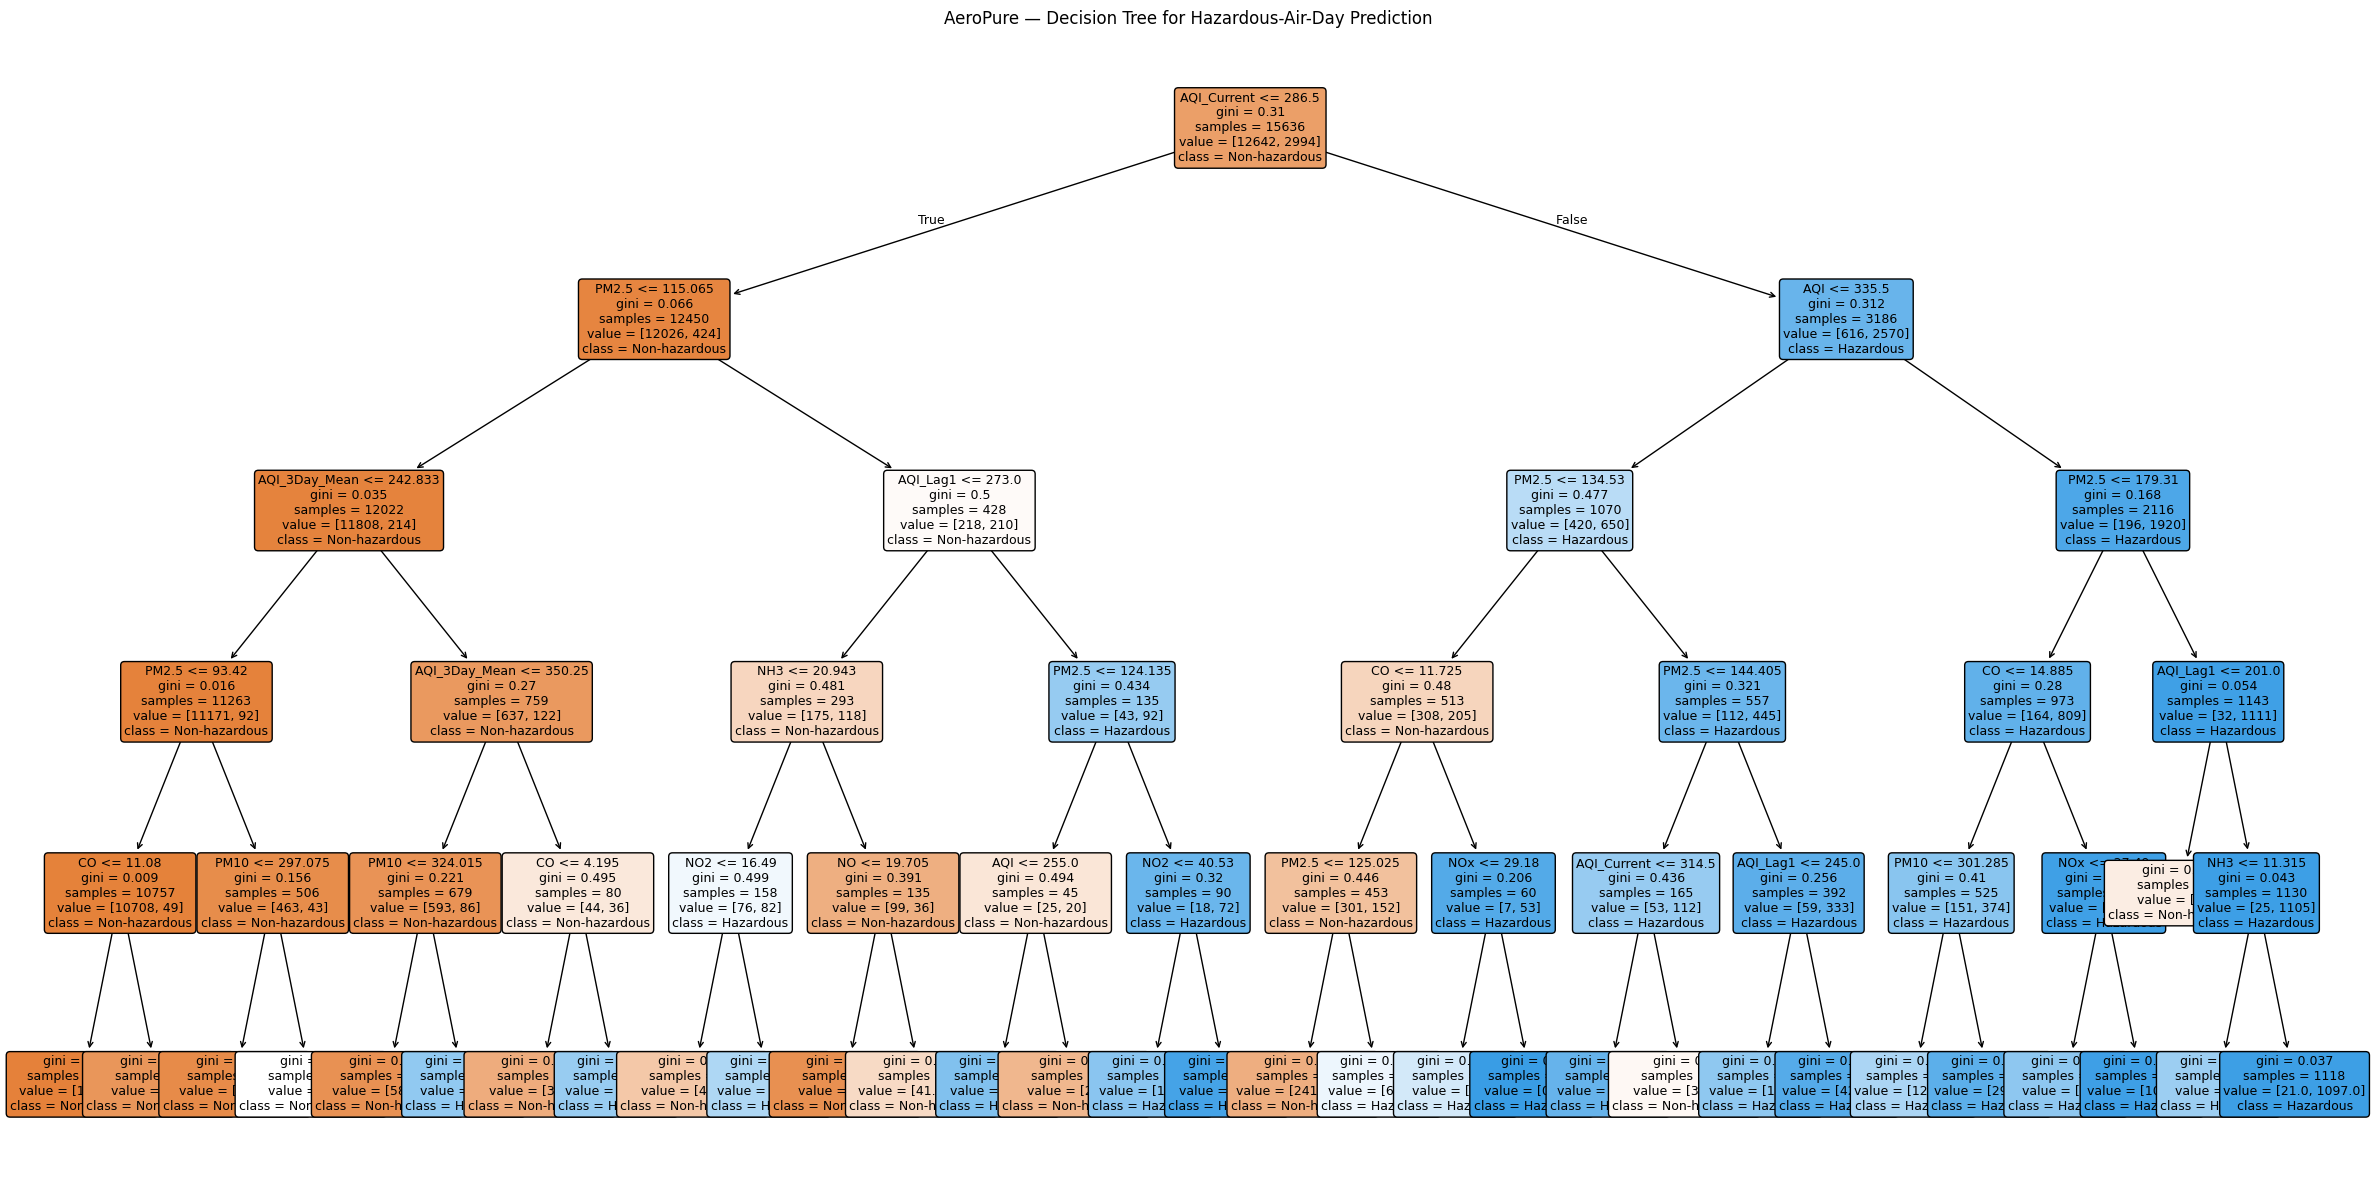

In [12]:
# ============================================================
# W6 CELL 7 — VISUALIZE DECISION TREE
# ============================================================

from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    decision_tree,
    feature_names=TREE_FEATURES,
    class_names=["Non-hazardous", "Hazardous"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("AeroPure — Decision Tree for Hazardous-Air-Day Prediction")
plt.tight_layout()
plt.show()

Decision Tree Feature Importance
      Feature  Importance
  AQI_Current    0.822363
        PM2.5    0.087653
          AQI    0.035628
           CO    0.019919
AQI_3Day_Mean    0.013016
     AQI_Lag1    0.006573
         PM10    0.006246
          NH3    0.003146
          NO2    0.002117
           NO    0.001716
          NOx    0.001623
      Benzene    0.000000
          SO2    0.000000
           O3    0.000000
      Toluene    0.000000
       Xylene    0.000000
    DayOfWeek    0.000000
        Month    0.000000


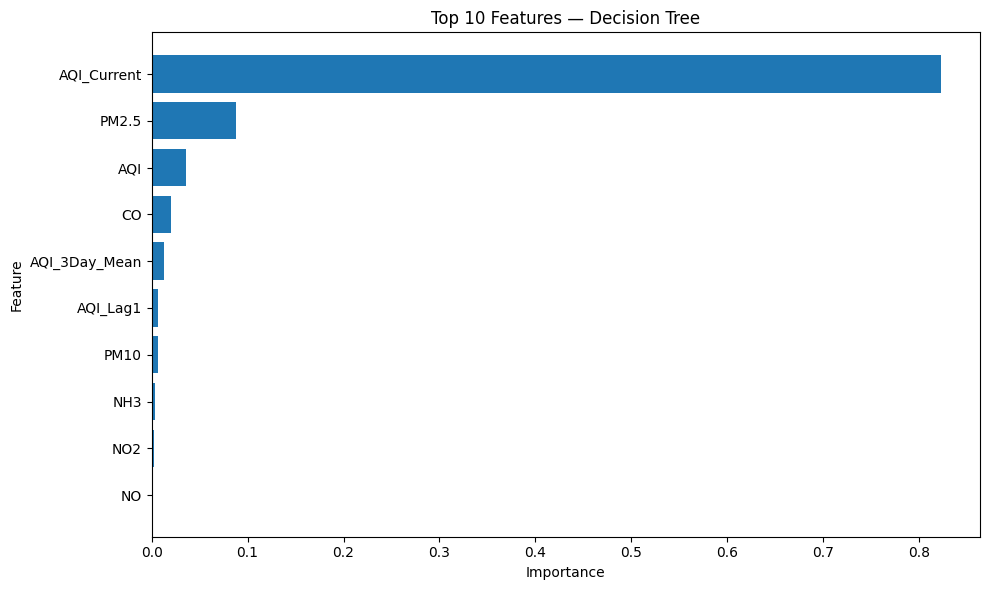

In [13]:
# ============================================================
# W6 CELL 8 — DECISION TREE FEATURE IMPORTANCE
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": TREE_FEATURES,
    "Importance": decision_tree.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Decision Tree Feature Importance")
print("=" * 45)
print(feature_importance.to_string(index=False))

# Plot top features
top_n = 10

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"].head(top_n)[::-1],
    feature_importance["Importance"].head(top_n)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features — Decision Tree")
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# W6 CELL 9 — CHECK AQI AND AQI_CURRENT RELATIONSHIP
# ============================================================

print("AQI and AQI_Current identical:",
      train_fe["AQI"].equals(train_fe["AQI_Current"]))

print("\nMaximum absolute difference:")
print(
    (train_fe["AQI"] - train_fe["AQI_Current"])
    .abs()
    .max()
)

AQI and AQI_Current identical: True

Maximum absolute difference:
0.0


In [15]:
# ============================================================
# W6 CELL 10 — CLEAN AND RETRAIN DECISION TREE
# ============================================================

# Remove duplicate AQI column
TREE_FEATURES_CLEAN = [
    col for col in TREE_FEATURES
    if col != "AQI"
]

X_train_tree_clean = train_fe[TREE_FEATURES_CLEAN].copy()
X_test_tree_clean = test_fe[TREE_FEATURES_CLEAN].copy()

# Median imputation fitted ONLY on training data
imputer_tree_clean = SimpleImputer(strategy="median")

X_train_tree_clean = imputer_tree_clean.fit_transform(
    X_train_tree_clean
)

X_test_tree_clean = imputer_tree_clean.transform(
    X_test_tree_clean
)

# Train cleaned Decision Tree
decision_tree_clean = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

decision_tree_clean.fit(
    X_train_tree_clean,
    y_train_tree
)

print("Cleaned Decision Tree trained successfully.")

print("\nFeatures used:", len(TREE_FEATURES_CLEAN))
print(TREE_FEATURES_CLEAN)

print("\nActual tree depth:", decision_tree_clean.get_depth())
print("Number of leaves:", decision_tree_clean.get_n_leaves())

Cleaned Decision Tree trained successfully.

Features used: 17
['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI_Current', 'AQI_Lag1', 'AQI_3Day_Mean', 'DayOfWeek', 'Month']

Actual tree depth: 5
Number of leaves: 31


In [16]:
# ============================================================
# W6 CELL 11 — EVALUATE CLEANED DECISION TREE
# ============================================================

# Predictions
y_pred_tree_clean = decision_tree_clean.predict(X_test_tree_clean)
y_prob_tree_clean = decision_tree_clean.predict_proba(
    X_test_tree_clean
)[:, 1]

# Metrics
clean_accuracy = accuracy_score(y_test_tree, y_pred_tree_clean)
clean_precision = precision_score(
    y_test_tree, y_pred_tree_clean, zero_division=0
)
clean_recall = recall_score(
    y_test_tree, y_pred_tree_clean, zero_division=0
)
clean_f1 = f1_score(
    y_test_tree, y_pred_tree_clean, zero_division=0
)
clean_roc_auc = roc_auc_score(
    y_test_tree, y_prob_tree_clean
)

print("Cleaned Decision Tree Test Results")
print("=" * 45)
print(f"Accuracy : {clean_accuracy:.4f}")
print(f"Precision: {clean_precision:.4f}")
print(f"Recall   : {clean_recall:.4f}")
print(f"F1 Score : {clean_f1:.4f}")
print(f"ROC-AUC  : {clean_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_tree, y_pred_tree_clean))

print("\nClassification Report:")
print(classification_report(
    y_test_tree,
    y_pred_tree_clean,
    target_names=["Non-hazardous", "Hazardous"],
    zero_division=0
))

Cleaned Decision Tree Test Results
Accuracy : 0.9756
Precision: 0.8038
Recall   : 0.8548
F1 Score : 0.8285
ROC-AUC  : 0.9810

Confusion Matrix:
[[7957  125]
 [  87  512]]

Classification Report:
               precision    recall  f1-score   support

Non-hazardous       0.99      0.98      0.99      8082
    Hazardous       0.80      0.85      0.83       599

     accuracy                           0.98      8681
    macro avg       0.90      0.92      0.91      8681
 weighted avg       0.98      0.98      0.98      8681



In [17]:
# ============================================================
# W6 CELL 12 — FINAL FEATURE IMPORTANCE
# ============================================================

final_importance = pd.DataFrame({
    "Feature": TREE_FEATURES_CLEAN,
    "Importance": decision_tree_clean.feature_importances_
})

final_importance = final_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("FINAL DECISION TREE FEATURE IMPORTANCE")
print("=" * 50)
print(final_importance.to_string(index=False))

FINAL DECISION TREE FEATURE IMPORTANCE
      Feature  Importance
  AQI_Current    0.857992
        PM2.5    0.087653
           CO    0.019919
AQI_3Day_Mean    0.013016
     AQI_Lag1    0.006573
         PM10    0.006246
          NH3    0.003146
          NO2    0.002117
           NO    0.001716
          NOx    0.001623
          SO2    0.000000
           O3    0.000000
      Benzene    0.000000
       Xylene    0.000000
      Toluene    0.000000
    DayOfWeek    0.000000
        Month    0.000000


In [18]:
# ============================================================
# W6 CELL 13 — TOP DECISION SPLITS
# ============================================================

from sklearn.tree import _tree

tree = decision_tree_clean.tree_

print("TOP DECISION TREE SPLITS")
print("=" * 50)

split_count = 0

for node in range(tree.node_count):

    # Skip leaf nodes
    if tree.feature[node] != _tree.TREE_UNDEFINED:

        feature = TREE_FEATURES_CLEAN[tree.feature[node]]
        threshold = tree.threshold[node]

        print(
            f"Split {split_count + 1}: "
            f"{feature} <= {threshold:.3f}"
        )

        split_count += 1

        if split_count == 10:
            break

TOP DECISION TREE SPLITS
Split 1: AQI_Current <= 286.500
Split 2: PM2.5 <= 115.065
Split 3: AQI_3Day_Mean <= 242.833
Split 4: PM2.5 <= 93.420
Split 5: CO <= 11.080
Split 6: PM10 <= 297.075
Split 7: AQI_3Day_Mean <= 350.250
Split 8: PM10 <= 324.015
Split 9: CO <= 4.195
Split 10: AQI_Lag1 <= 273.000


In [19]:
# ============================================================
# W6 CELL 14 — SAVE FINAL W6 RESULTS
# ============================================================

# Save feature importance
final_importance.to_csv(
    "../data/w6_decision_tree_feature_importance.csv",
    index=False
)

# Save model performance
w6_results = pd.DataFrame({
    "Model": ["Decision Tree"],
    "Accuracy": [clean_accuracy],
    "Precision": [clean_precision],
    "Recall": [clean_recall],
    "F1": [clean_f1],
    "ROC_AUC": [clean_roc_auc],
    "Max_Depth": [decision_tree_clean.max_depth],
    "Leaves": [decision_tree_clean.get_n_leaves()]
})

w6_results.to_csv(
    "../data/w6_decision_tree_results.csv",
    index=False
)

print("W6 results saved successfully.")

print("\nFinal W6 Result:")
print(w6_results.to_string(index=False))

W6 results saved successfully.

Final W6 Result:
        Model  Accuracy  Precision   Recall       F1  ROC_AUC  Max_Depth  Leaves
Decision Tree  0.975579   0.803768 0.854758 0.828479 0.980991          5      31
